In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import pickle

In [15]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [16]:
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, inplace=True)

In [17]:
##Encode target
label = LabelEncoder()
df["Attrition"] = label.fit_transform(df["Attrition"])

In [19]:
# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

In [22]:
# Split data
X = df.drop("Attrition", axis=1)
y = df["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [23]:
# Scaling (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# ------------------ Logistic Regression ------------------
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("LOGISTIC REGRESSION")
print(confusion_matrix(y_test, y_pred_lr))
print(accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION
[[359  11]
 [ 42  29]]
0.8798185941043084
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       370
           1       0.72      0.41      0.52        71

    accuracy                           0.88       441
   macro avg       0.81      0.69      0.73       441
weighted avg       0.87      0.88      0.87       441



In [26]:
# ------------------ Random Forest ------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RANDOM FOREST")
print(confusion_matrix(y_test, y_pred_rf))
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST
[[359  11]
 [ 62   9]]
0.8344671201814059
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       370
           1       0.45      0.13      0.20        71

    accuracy                           0.83       441
   macro avg       0.65      0.55      0.55       441
weighted avg       0.79      0.83      0.79       441



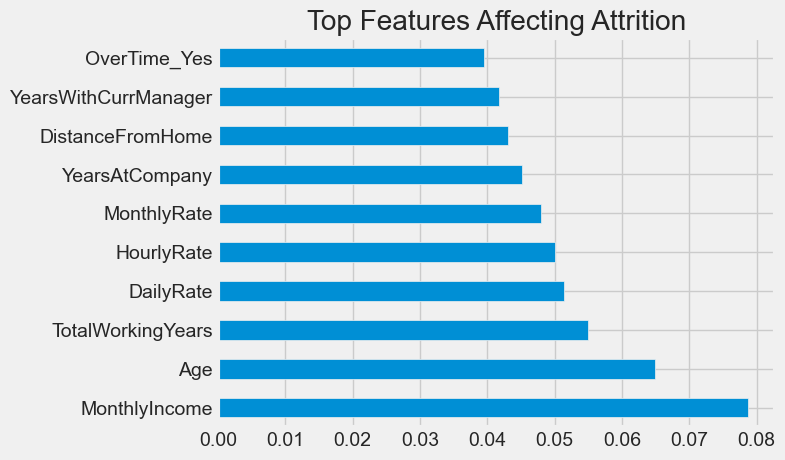

In [27]:
# Feature Importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.title("Top Features Affecting Attrition")
plt.show()

In [28]:
# Save model
with open("../model/attrition_model.pkl", "wb") as f:
    pickle.dump(rf, f)

# Save features
with open("../model/features.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)